In [ ]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dfs = {}

for file in os.listdir():
    if file[-4:] == 'json':
        chunks = pd.read_json(file, lines=True, chunksize=100000)
        dfs[file[:-5]] = pd.concat(chunks)

In [ ]:
list(dfs.keys())

['yelp_academic_dataset_business',
 'yelp_academic_dataset_checkin',
 'yelp_academic_dataset_review',
 'yelp_academic_dataset_tip',
 'yelp_academic_dataset_user']

In [ ]:
for file_name,df in dfs.items():
  print(file_name)
  print(df.info())

yelp_academic_dataset_business
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  object 
 1   name          150346 non-null  object 
 2   address       150346 non-null  object 
 3   city          150346 non-null  object 
 4   state         150346 non-null  object 
 5   postal_code   150346 non-null  object 
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  object 
 12  categories    150243 non-null  object 
 13  hours         127123 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 16.1+ MB
None
yelp_academic_dataset_checkin
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131930

### Business EDA

In [ ]:
df = dfs['yelp_academic_dataset_business']
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,150346.0,36.671150,5.872759,27.555127,32.187293,38.777413,39.954036,53.679197
longitude,150346.0,-89.357339,14.918502,-120.095137,-90.357810,-86.121179,-75.421542,-73.200457
stars,150346.0,3.596724,0.974421,1.000000,3.000000,3.500000,4.500000,5.000000
review_count,150346.0,44.866561,121.120136,5.000000,8.000000,15.000000,37.000000,7568.000000
is_open,150346.0,0.796150,0.402860,0.000000,1.000000,1.000000,1.000000,1.000000


latitude


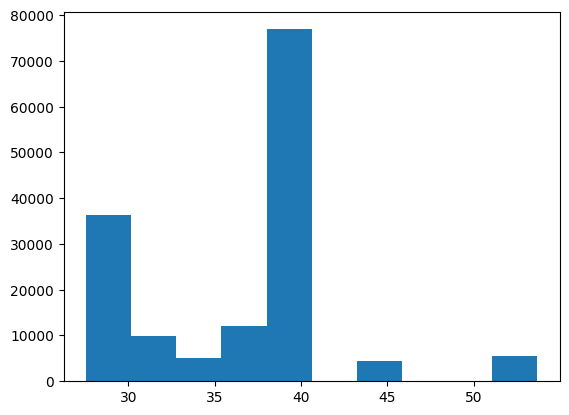

longitude


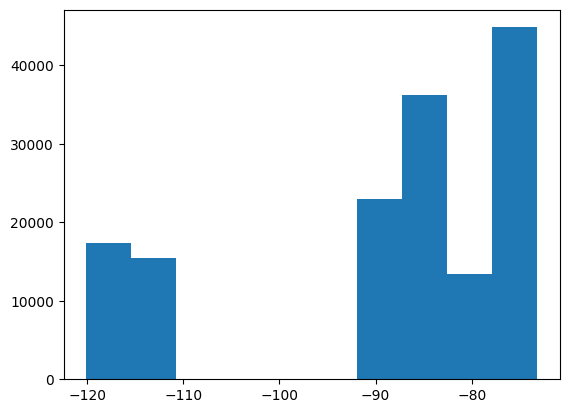

stars


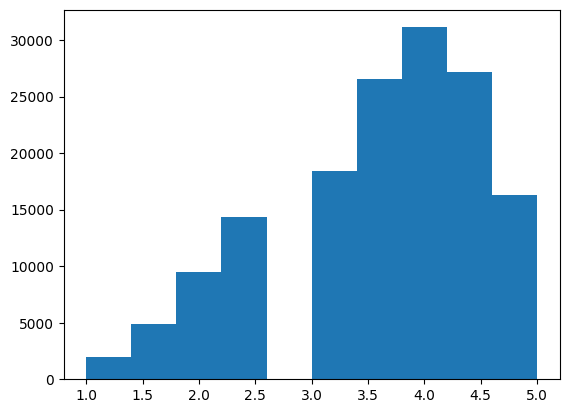

review_count


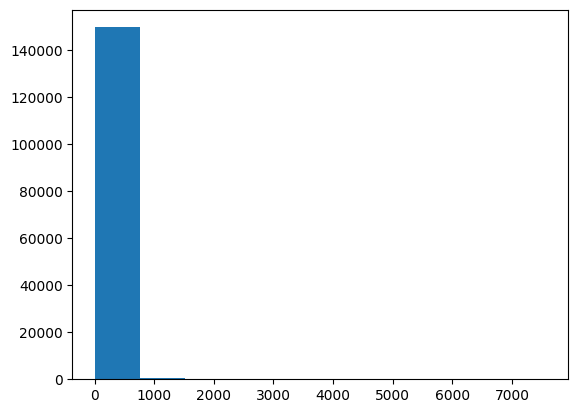

is_open


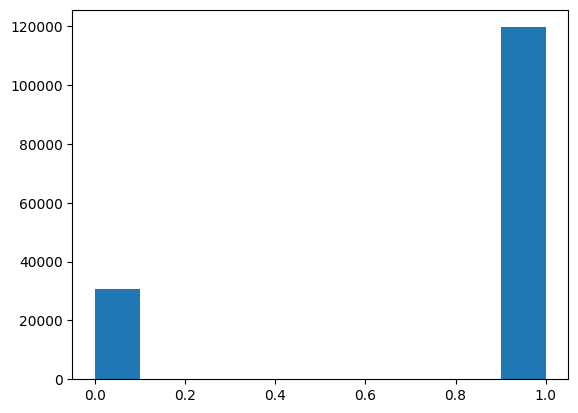

In [ ]:
for col in df.select_dtypes(include=["int", "float"]):
    plt.hist(df[col])
    print(col)
    plt.show()

In [ ]:
df.isnull().sum()

business_id         0
name                0
address             0
city                0
state               0
postal_code         0
latitude            0
longitude           0
stars               0
review_count        0
is_open             0
attributes      13744
categories        103
hours           23223
dtype: int64

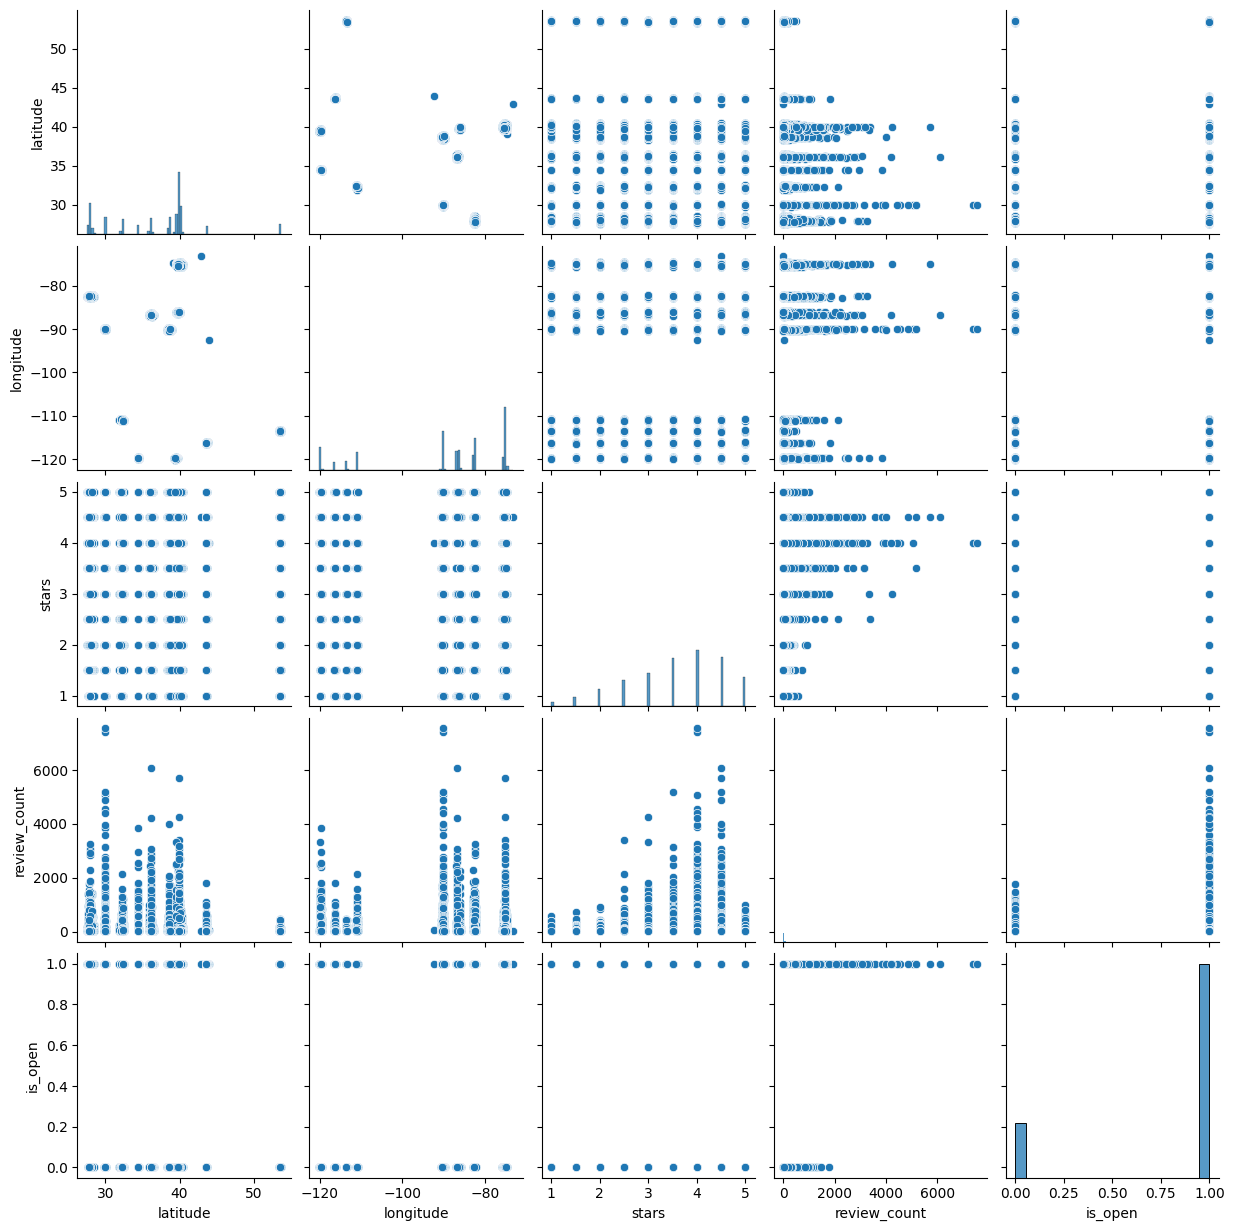

In [ ]:
sns.pairplot(df)

In [ ]:
df.corr(numeric_only=True)

,latitude,longitude,stars,review_count,is_open
latitude,1.000000,-0.135796,-0.036312,-0.046294,-0.016721
longitude,-0.135796,1.000000,-0.056114,-0.008820,-0.014275
stars,-0.036312,-0.056114,1.000000,0.059876,0.044992
review_count,-0.046294,-0.008820,0.059876,1.000000,0.029654
is_open,-0.016721,-0.014275,0.044992,0.029654,1.000000


### Review EDA

In [ ]:
df = dfs['yelp_academic_dataset_review']
df.describe().T

,count,mean,min,25%,50%,75%,max,std
stars,6990280.0,3.748584,1.0,3.0,4.0,5.0,5.0,1.478705
useful,6990280.0,1.184609,-1.0,0.0,0.0,1.0,1182.0,3.253767
funny,6990280.0,0.32656,-1.0,0.0,0.0,0.0,792.0,1.688729
cool,6990280.0,0.498618,-1.0,0.0,0.0,0.0,404.0,2.17246
date,6990280,2017-01-11 11:22:33.441780992,2005-02-16 03:23:22,2015-01-25 04:53:50.249999872,2017-06-03 01:26:07,2019-05-23 00:02:46.249999872,2022-01-19 19:48:45,NaN


In [ ]:
df.text.str.len().describe()

count    6.990280e+06
mean     5.677644e+02
std      5.272578e+02
min      1.000000e+00
25%      2.290000e+02
50%      4.060000e+02
75%      7.200000e+02
max      5.000000e+03
Name: text, dtype: float64

stars


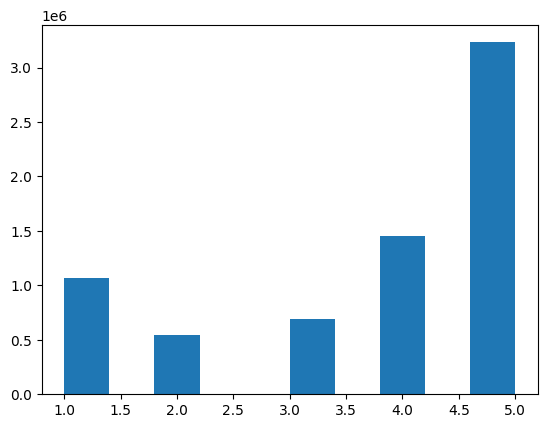

useful


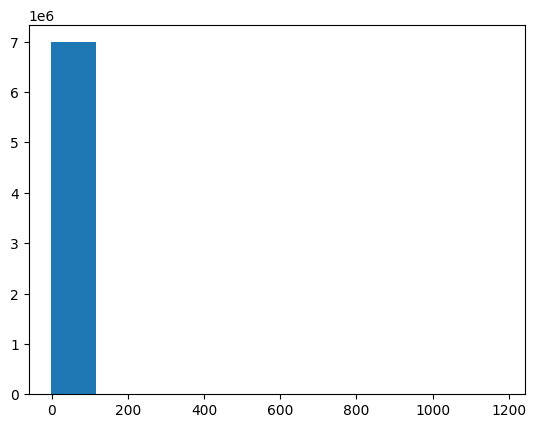

funny


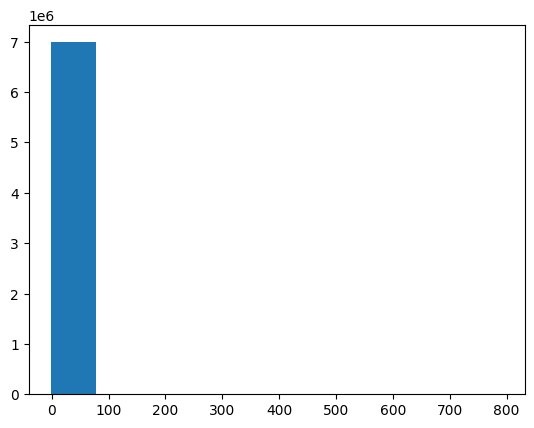

cool


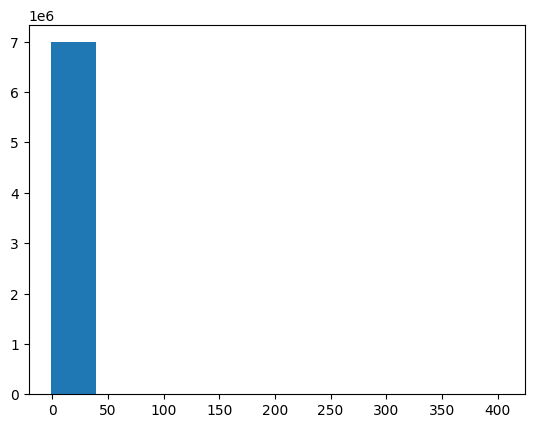

In [ ]:
for col in df.select_dtypes(include=["int", "float"]):
    plt.hist(df[col])
    print(col)
    plt.show()

In [ ]:
df.isnull().sum()

review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

In [ ]:
df.corr(numeric_only=True)

,stars,useful,funny,cool
stars,1.000000,-0.072458,-0.043217,0.068827
useful,-0.072458,1.000000,0.511803,0.718529
funny,-0.043217,0.511803,1.000000,0.607310
cool,0.068827,0.718529,0.607310,1.000000


### User EDA

In [ ]:
df = dfs['yelp_academic_dataset_user']
df.describe().T

,count,mean,std,min,25%,50%,75%,max
review_count,1987897.0,23.394409,82.566992,0.0,2.0,5.00,17.00,17473.0
useful,1987897.0,42.296335,641.480597,0.0,0.0,3.00,13.00,206296.0
funny,1987897.0,16.970536,407.803437,0.0,0.0,0.00,2.00,185823.0
cool,1987897.0,23.792914,565.351295,0.0,0.0,0.00,3.00,199878.0
fans,1987897.0,1.465740,18.130753,0.0,0.0,0.00,0.00,12497.0
average_stars,1987897.0,3.630494,1.183337,1.0,3.0,3.88,4.56,5.0
compliment_hot,1987897.0,1.807072,73.601841,0.0,0.0,0.00,0.00,25784.0
compliment_more,1987897.0,0.292263,12.824667,0.0,0.0,0.00,0.00,13501.0
compliment_profile,1987897.0,0.179318,15.155253,0.0,0.0,0.00,0.00,14180.0
compliment_cute,1987897.0,0.133649,11.356823,0.0,0.0,0.00,0.00,13654.0


In [ ]:
101097.0/3.011841

33566.512973294404

review_count


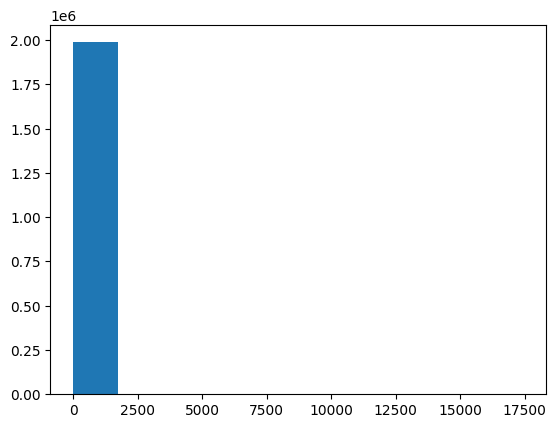

useful


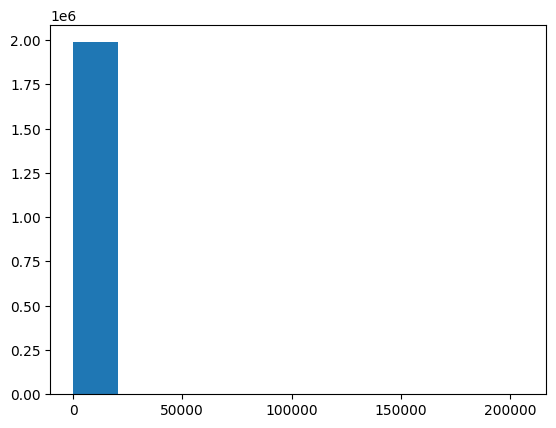

funny


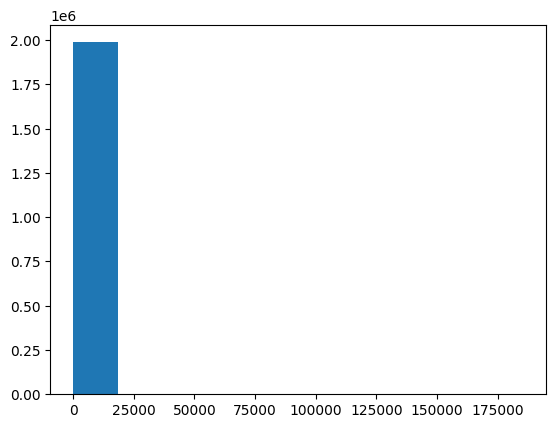

cool


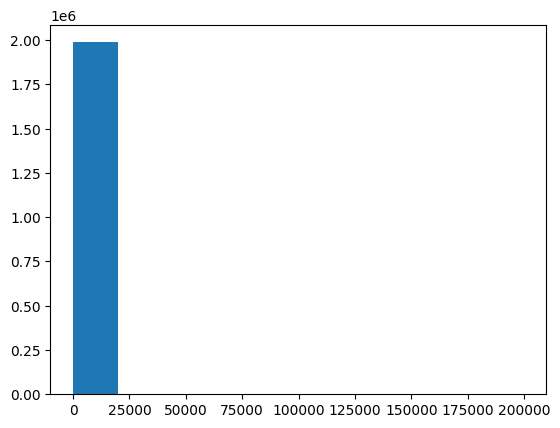

fans


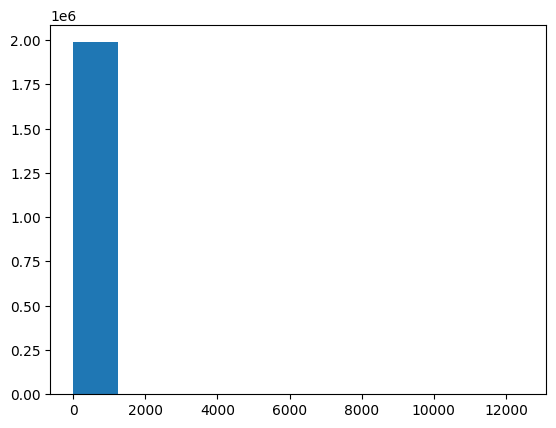

average_stars


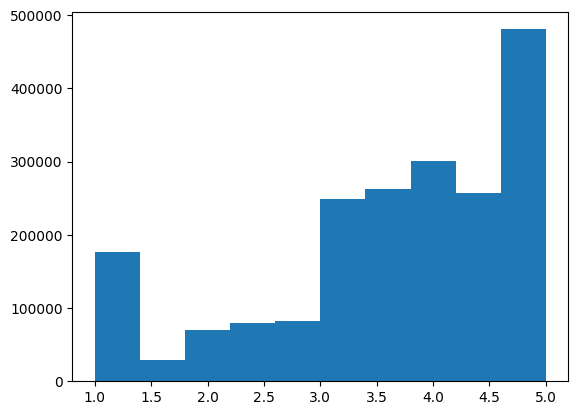

compliment_hot


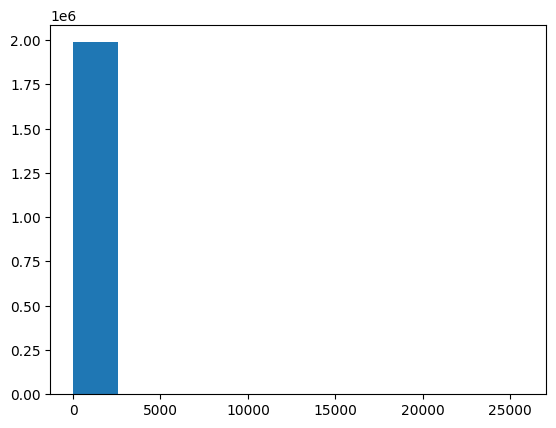

compliment_more


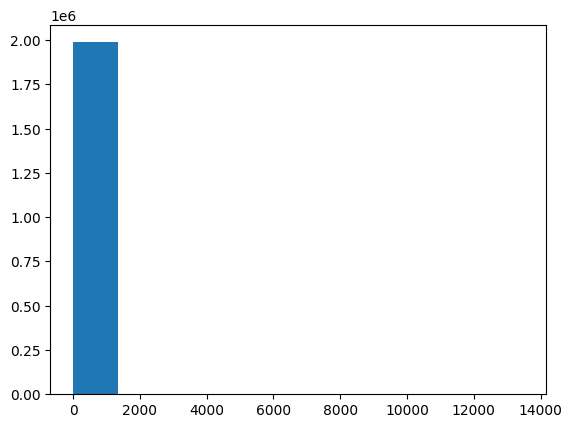

compliment_profile


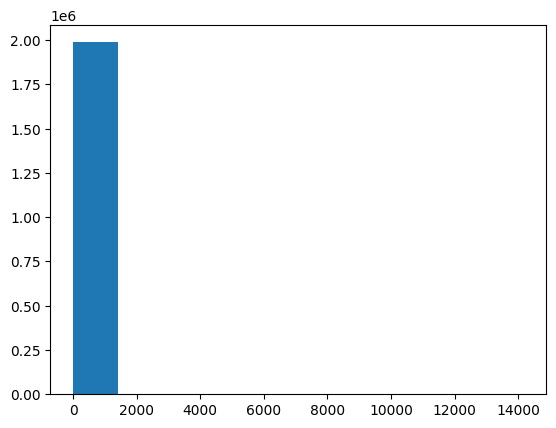

compliment_cute


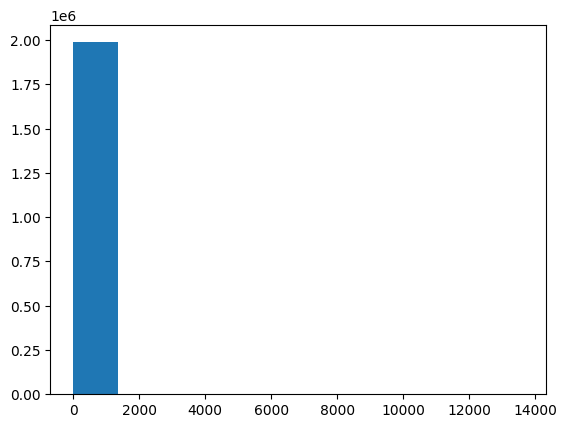

compliment_list


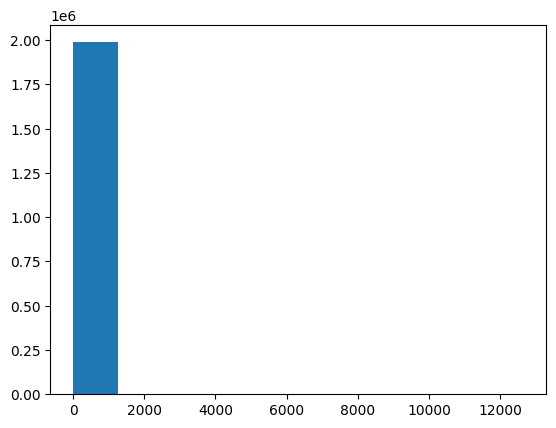

compliment_note


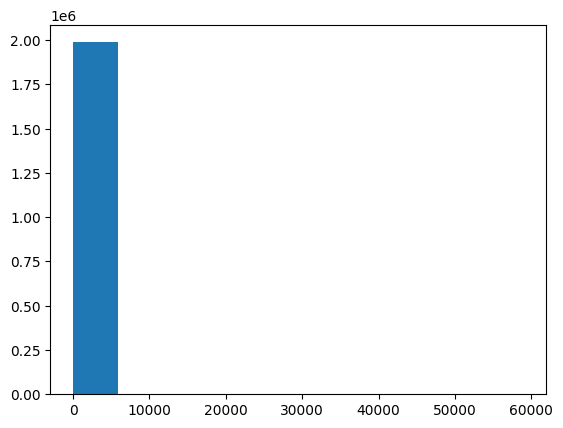

compliment_plain


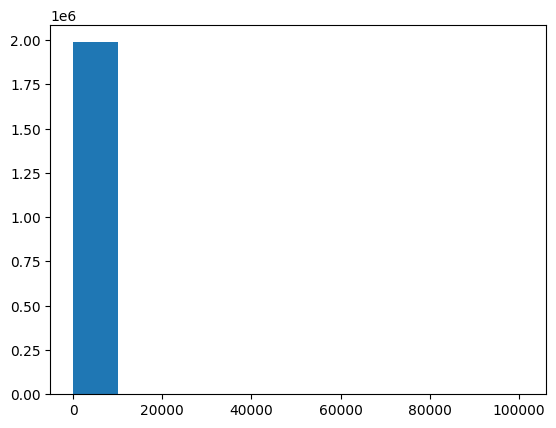

compliment_cool


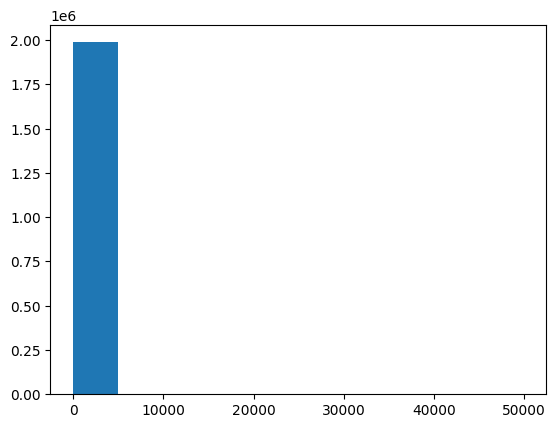

compliment_funny


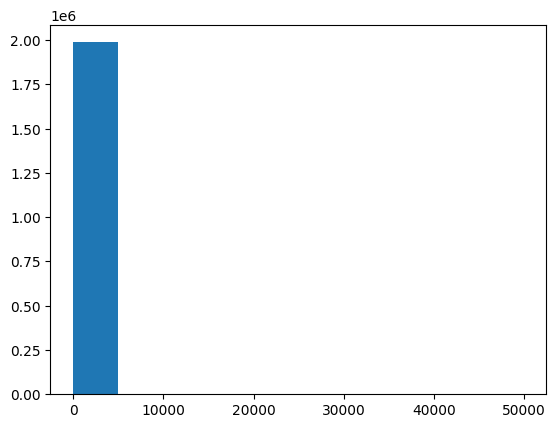

compliment_writer


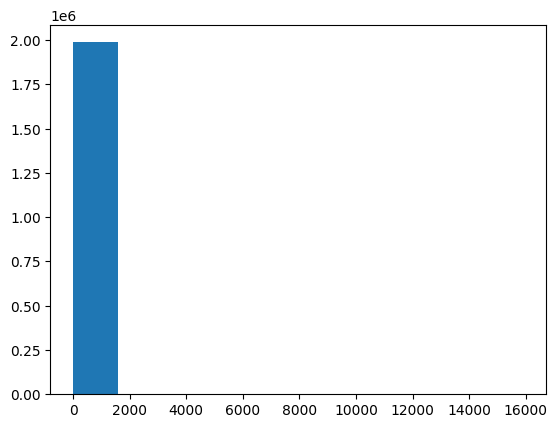

compliment_photos


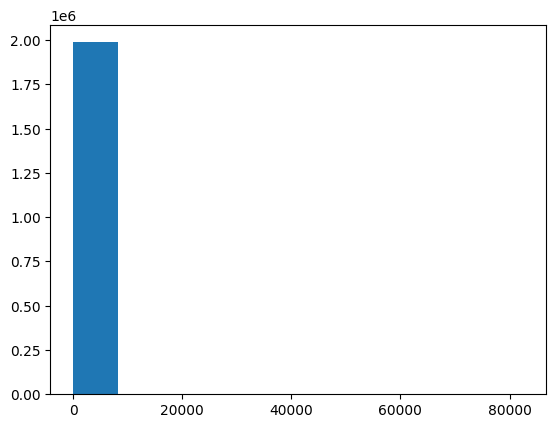

In [ ]:
for col in df.select_dtypes(include=["int", "float"]):
    plt.hist(df[col])
    print(col)
    plt.show()

In [ ]:
df.isnull().sum()

user_id               0
name                  0
review_count          0
yelping_since         0
useful                0
funny                 0
cool                  0
elite                 0
friends               0
fans                  0
average_stars         0
compliment_hot        0
compliment_more       0
compliment_profile    0
compliment_cute       0
compliment_list       0
compliment_note       0
compliment_plain      0
compliment_cool       0
compliment_funny      0
compliment_writer     0
compliment_photos     0
dtype: int64

In [ ]:
df.corr(numeric_only=True)

,review_count,useful,funny,cool,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
review_count,1.000000,0.573369,0.476440,0.494112,0.534190,0.045380,0.262447,0.189265,0.135110,0.120866,0.083666,0.209687,0.267455,0.301840,0.301840,0.333263,0.150500
useful,0.573369,1.000000,0.954307,0.991841,0.643238,0.010973,0.614303,0.426293,0.360189,0.262687,0.203699,0.433614,0.663199,0.735886,0.735886,0.700046,0.546947
funny,0.476440,0.954307,1.000000,0.964872,0.590613,0.007060,0.661326,0.476574,0.409498,0.303063,0.235382,0.441846,0.673973,0.772529,0.772529,0.757250,0.581671
cool,0.494112,0.991841,0.964872,1.000000,0.600828,0.010437,0.630804,0.436831,0.373656,0.270682,0.210513,0.436336,0.671736,0.754928,0.754928,0.707368,0.574912
fans,0.534190,0.643238,0.590613,0.600828,1.000000,0.019413,0.425691,0.257129,0.204807,0.199979,0.121405,0.321864,0.526995,0.484914,0.484914,0.459413,0.296039
average_stars,0.045380,0.010973,0.007060,0.010437,0.019413,1.000000,0.005928,0.004485,0.002745,0.002601,0.001425,0.004902,0.006592,0.007309,0.007309,0.007370,0.003890
compliment_hot,0.262447,0.614303,0.661326,0.630804,0.425691,0.005928,1.000000,0.627411,0.609600,0.546024,0.434293,0.721171,0.682982,0.882702,0.882702,0.802483,0.721363
compliment_more,0.189265,0.426293,0.476574,0.436831,0.257129,0.004485,0.627411,1.000000,0.961363,0.919417,0.931902,0.448723,0.563017,0.666685,0.666685,0.803428,0.825297
compliment_profile,0.135110,0.360189,0.409498,0.373656,0.204807,0.002745,0.609600,0.961363,1.000000,0.890371,0.908688,0.421115,0.558923,0.639783,0.639783,0.774470,0.785596
compliment_cute,0.120866,0.262687,0.303063,0.270682,0.199979,0.002601,0.546024,0.919417,0.890371,1.000000,0.957817,0.357084,0.438571,0.526734,0.526734,0.641525,0.764134
